# Breathing Geofence — Hourly Adaptation (March 1, 08:00–14:00)

**Purpose:** Model how the optimal geofence changes hour-by-hour as demand shifts
within a single day. Compare a fixed *static* geofence (SA-optimised on 6-hour
cumulative revenue) against a *breathing* geofence that adapts each hour.

**Key question:** Does a geofence that breathes with hourly demand capture more
revenue than a fixed zone — and at what cost in zone stability?

**Approach:**
1. Build one **static** geofence using SA on cumulative 08:00–14:00 revenue.
2. Build an **08:00** geofence using SA on that hour's trips alone.
3. For **09:00–13:00**, adapt the previous hour's geofence via `run_transition`:
   - *Border contract*  peel zero-revenue blocks from the zone's outer edge,
     tip-first (fewest internal neighbours first); interior blocks are untouched.
   - *Swap*  migrate toward better territory under the new demand signal.
   - *Expand*  grow into adjacent blocks if area cap permits.
   - *Border continuity (Option C)* — ensure every dropped block is adjacent
     to the new zone, so cars can physically reach it within the hour.

**Revenue semantics:** evaluation uses *pickup-committed* revenue —
a trip is credited to whichever hour's zone accepted it (pickup block in zone),
regardless of where the dropoff occurs or whether the trip spans the hour boundary.

**Result** In a result revenue ended up to be lower, mainly beacuse I did not manage to take into account cases when the ride started, for instance at 8.55 and finished at 9.15 in the block that is no longer in geofence. 

**What would be nice to consider inthe future, but fixing revenue function***
- Take into account future predictions for neighbouring block to bring higher revenue, for instance by adding share of neighbouring blocks future margins in algorithm. To make the graph anticipate the change.

**Contents**

1. Imports & load data
2. Join dates & hours — filter to March 1, 08:00–14:00
3. Static geofence — SA on cumulative 6-hour revenue
4. Hourly revenue lookups — demand variation across hours
5. Hour 08:00 — fresh SA + checkpoint save
6. Hours 09:00–13:00 — hourly transitions with border continuity
7. Transition maps — added/removed blocks per hour
8. Revenue comparison — static vs. breathing
9. Summary table

## 1. Imports & load data

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.ops import unary_union

import src.config as cfg
from src.blocks import load_osm_data
from src.revenue import (
    build_block_lookup,
    compute_revenue,
    compute_pickup_revenue,
    find_local_maxima_seeds,
)
from src.optimiser import build_adjacency, run_multi_start
from src.breathing import (
    load_dated_trips,
    build_hourly_lookups,
    build_cumulative_lookup,
    run_transition,
    diff_geofences,
    project_bbox,
    plot_transition,
)

# ── Load data ──────────────────────────────────────────────────────────────────
blocks_main = gpd.read_file(cfg.FILTERED_BLOCKS_FILE)
trips       = pd.read_csv(cfg.TRIPS_ASSIGNED_FILE)
quotes      = pd.read_parquet(cfg.QUOTES_CANONICAL_FILE)
_, roads    = load_osm_data(cfg.PBF_FILE, cfg.CENTER_BBOX, cfg.ROAD_TYPES, cfg.TARGET_CRS)

# ── Shared structures — built once, reused throughout ─────────────────────────
adjacency     = build_adjacency(blocks_main)
block_area_m2 = dict(zip(blocks_main["block_id"], blocks_main.geometry.area))  # {block_id: area_m²}
bbox_bounds   = project_bbox(cfg.CENTER_BBOX, cfg.TARGET_CRS)                  # (xmin, ymin, xmax, ymax)

print(f"Blocks: {len(blocks_main):,}  |  Trips: {len(trips):,}  |  Quotes: {len(quotes):,}")

Roads loaded:  47,041
Road types:    ['living_street', 'motorway', 'motorway_link', 'primary', 'primary_link', 'residential', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link']
CRS:           EPSG:27700


Building adjacency: 100%|██████████| 29480/29480 [00:14<00:00, 2026.33it/s]

Blocks: 29,480  |  Trips: 190,446  |  Quotes: 511,796


## 2. Join dates & hours — filter to March 1, 08:00–14:00

In [2]:
import datetime

MARCH_DATE = datetime.date(2026, 3, 1)
HOURS      = [8, 9, 10, 11, 12, 13]   # 08:00–09:00 through 13:00–14:00

# Join quote_creation_timestamp onto trips; extract London date and hour
dated_trips = load_dated_trips(trips, quotes)
dated_window = dated_trips[
    (dated_trips["date"] == MARCH_DATE) &
    (dated_trips["hour"].isin(HOURS))
].copy()

trips_per_hour = dated_window.groupby("hour").size().reset_index(name="n_trips")
trips_per_hour["window"] = trips_per_hour["hour"].map(
    lambda h: f"{h:02d}:00\u2013{h+1:02d}:00"
)
print(f"Trips in window (March 1, 08:00\u201314:00): {len(dated_window):,}")
print()
print(trips_per_hour[["window", "n_trips"]].to_string(index=False))

Trips in window (March 1, 08:00–14:00): 1,343

     window  n_trips
08:00–09:00       86
09:00–10:00      185
10:00–11:00      221
11:00–12:00      255
12:00–13:00      314
13:00–14:00      282


## 3. Static geofence — SA on cumulative 08:00–14:00 revenue

Baseline: one geofence optimised on all 6 hours of demand combined.
This represents a zone set once in the morning and held fixed all day.

In [3]:
T_START      = 300.0
T_END        = 1.0
COOLING_RATE = 0.995
SA_MAX_ITERS = 1000

# ── Cumulative lookup: all 6 hours combined ────────────────────────────────────
cumulative_lookup = build_cumulative_lookup(dated_window, MARCH_DATE, HOURS)
cumulative_bl     = build_block_lookup(cumulative_lookup)

total_rev_6h = compute_revenue(set(blocks_main["block_id"]), cumulative_lookup)
print(f"Total convertible revenue (6-hour cumulative): £{total_rev_6h:,.2f}")

# ── Seeds from cumulative signal ──────────────────────────────────────────────
cumulative_seeds, _ = find_local_maxima_seeds(
    blocks_main, adjacency, cumulative_bl,
    k=cfg.N_SEEDS, center_bbox=cfg.CENTER_BBOX,
)

# ── SA multi-start on cumulative data ─────────────────────────────────────────
print("\n=== STATIC GEOFENCE — SA on cumulative 08:00–14:00 ===")
static_sel, static_rev, _, _, _ = run_multi_start(
    cumulative_seeds, adjacency, cumulative_bl, block_area_m2,
    mode="sa",
    T_start=T_START, T_end=T_END, cooling_rate=COOLING_RATE,
    max_area_sqkm=cfg.MAX_AREA_SQKM,
    max_iters=SA_MAX_ITERS,
)

static_area = unary_union(
    blocks_main[blocks_main["block_id"].isin(static_sel)].geometry
).area / 1e6
print(
    f"\nStatic geofence: {len(static_sel)} blocks  |  "
    f"area: {static_area:.2f} sq km  |  "
    f"cumulative revenue: £{static_rev:,.2f}"
)

# ── Save checkpoint — reload to skip re-running static SA ─────────────────────
import pickle, pathlib

RESULTS_DIR = pathlib.Path("../data/processed/breathing_results")
RESULTS_DIR.mkdir(exist_ok=True)

with open(RESULTS_DIR / "checkpoint_static.pkl", "wb") as f:
    pickle.dump({
        "static_sel":  static_sel,
        "static_rev":  static_rev,
        "static_area": static_area,
    }, f)
print(f"Checkpoint saved → {RESULTS_DIR / 'checkpoint_static.pkl'}")

Total convertible revenue (6-hour cumulative): £35,450.93
Seed candidates restricted to center_bbox: 9,113 blocks
Local revenue maxima found: 5,109
  Seed 1: block_id=1819, unilateral_rev=£804.68
  Seed 2: block_id=549, unilateral_rev=£664.25
  Seed 3: block_id=23399, unilateral_rev=£601.92
  Seed 4: block_id=15630, unilateral_rev=£404.58
  Seed 5: block_id=2701, unilateral_rev=£393.02

=== STATIC GEOFENCE — SA on cumulative 08:00–14:00 ===

──────────────────────────────────────────────────
Run 1/5  seed=1819  mode=sa
──────────────────────────────────────────────────
Seed 1819  rev=£0.00  T_start=300.0  cooling=0.995
Converged at iteration 723.
RESULT  seed=1819  blocks=717  best_rev=£3,969.75  final_rev=£3,969.75  area=15.00 sqkm

──────────────────────────────────────────────────
Run 2/5  seed=549  mode=sa
──────────────────────────────────────────────────
Seed 549  rev=£0.00  T_start=300.0  cooling=0.995
Converged at iteration 593.
RESULT  seed=549  blocks=583  best_rev=£2,493.04 

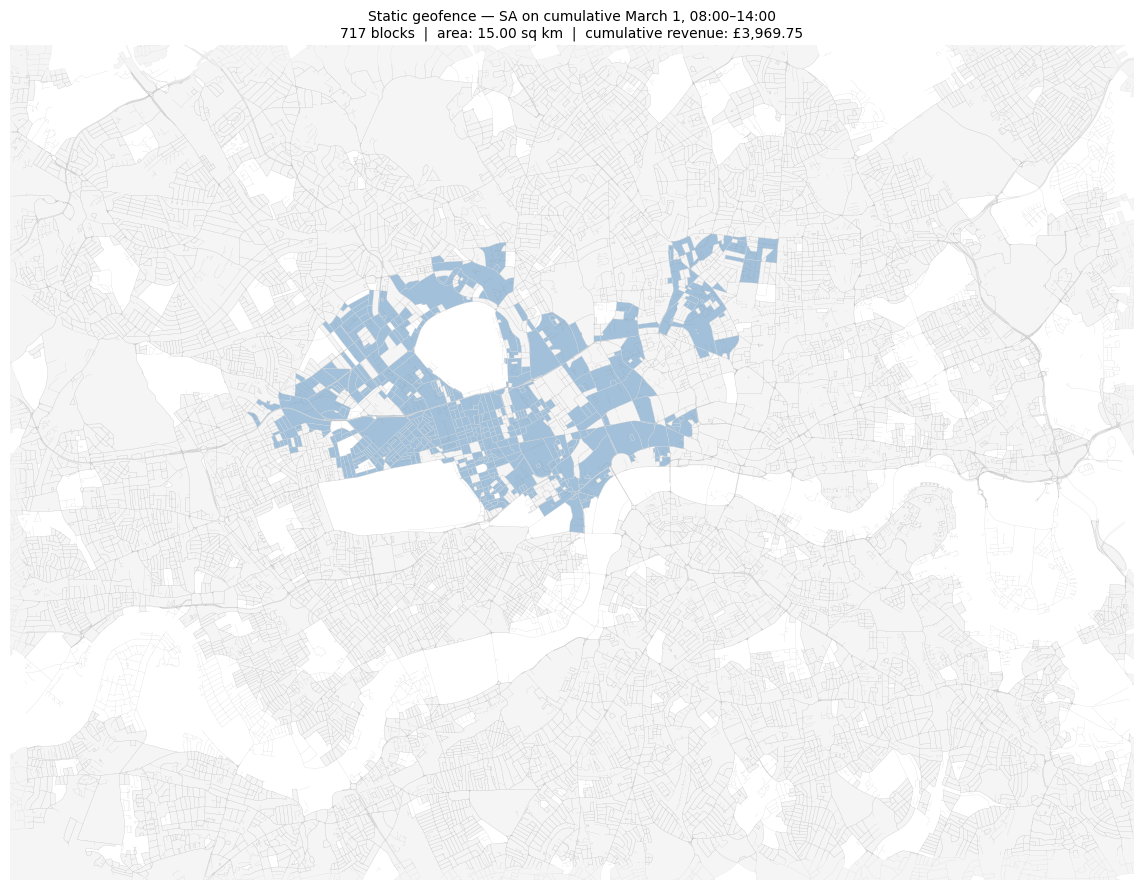

In [4]:
fig, ax = plt.subplots(figsize=(12, 9))

roads.plot(ax=ax, linewidth=0.2, color="grey", alpha=0.3)
blocks_main[~blocks_main["block_id"].isin(static_sel)].plot(
    ax=ax, color="#f5f5f5", edgecolor="#dddddd", linewidth=0.15
)
blocks_main[blocks_main["block_id"].isin(static_sel)].plot(
    ax=ax, color="steelblue", alpha=0.5, edgecolor="white", linewidth=0.3
)

xmin, ymin, xmax, ymax = bbox_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    f"Static geofence \u2014 SA on cumulative March 1, 08:00\u201314:00\n"
    f"{len(static_sel)} blocks  |  area: {static_area:.2f} sq km  |  "
    f"cumulative revenue: \u00a3{static_rev:,.2f}",
    fontsize=10,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Hourly revenue lookups — demand variation across hours

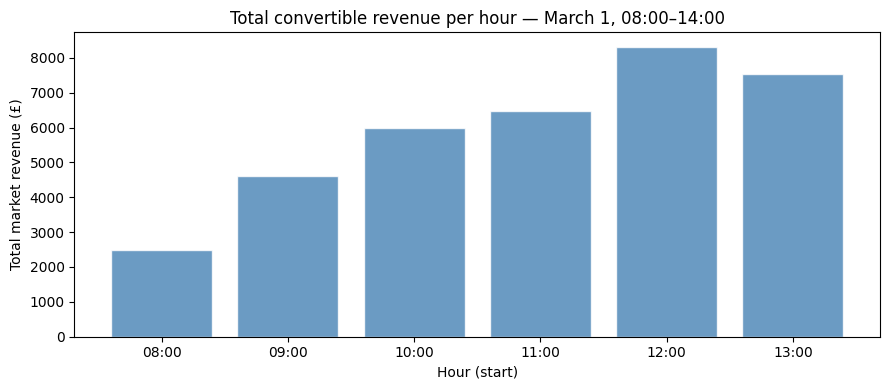

Hourly total convertible revenue:
  08:00–09:00  £2,494.44
  09:00–10:00  £4,615.58
  10:00–11:00  £5,996.95
  11:00–12:00  £6,484.68
  12:00–13:00  £8,314.62
  13:00–14:00  £7,544.66


In [5]:
# Raw revenue_lookups per hour: {(pickup_block, dropoff_block): revenue}
hourly_lookups = build_hourly_lookups(dated_window, MARCH_DATE, HOURS)

# Block_lookups per hour: {block_id: {other_block_id: revenue}} — for transition functions
hourly_bls = {h: build_block_lookup(hourly_lookups[h]) for h in HOURS}

# Total market revenue available per hour
hourly_total_rev = {
    h: compute_revenue(set(blocks_main["block_id"]), hourly_lookups[h])
    for h in HOURS
}

hour_labels = [f"{h:02d}:00" for h in HOURS]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hour_labels, [hourly_total_rev[h] for h in HOURS],
       color="steelblue", alpha=0.8, edgecolor="white")
ax.set_xlabel("Hour (start)")
ax.set_ylabel("Total market revenue (\u00a3)")
ax.set_title("Total convertible revenue per hour \u2014 March 1, 08:00\u201314:00")
plt.tight_layout()
plt.show()

print("Hourly total convertible revenue:")
for h in HOURS:
    print(f"  {h:02d}:00\u2013{h+1:02d}:00  \u00a3{hourly_total_rev[h]:,.2f}")

## 5. Hour 08:00 — fresh SA

The breathing sequence starts from a geofence optimised purely on 08:00–09:00
demand. Seeds are derived from that hour's revenue signal.

In [6]:
h8_bl = hourly_bls[8]

print("=== 08:00 — seeds from hour-8 revenue ===")
h8_seeds, _ = find_local_maxima_seeds(
    blocks_main, adjacency, h8_bl,
    k=cfg.N_SEEDS, center_bbox=cfg.CENTER_BBOX,
)

print("\n=== 08:00 — SA multi-start on 08:00–09:00 trips ===")
sel_h8, _, _, _, _ = run_multi_start(
    h8_seeds, adjacency, h8_bl, block_area_m2,
    mode="sa",
    T_start=T_START, T_end=T_END, cooling_rate=COOLING_RATE,
    max_area_sqkm=cfg.MAX_AREA_SQKM,
    max_iters=SA_MAX_ITERS,
)

rev_h8  = compute_pickup_revenue(sel_h8, hourly_lookups[8])
area_h8 = sum(block_area_m2.get(b, 0) for b in sel_h8) / 1e6
print(f"\n08:00: {len(sel_h8)} blocks  |  area: {area_h8:.2f} sq km  |  revenue: £{rev_h8:,.2f}")

# Initialise tracking lists
geofences  = [sel_h8]
revenues   = [rev_h8]
stats_list = [{
    "hour":            8,
    "n_removed":       0,
    "n_swapped":       0,
    "n_added":         len(sel_h8),
    "n_bridge_blocks": 0,
    "n_blocks":        len(sel_h8),
    "area_sqkm":       area_h8,
}]

# ── Save checkpoint — reload from here to skip re-running SA ──────────────────
import pickle, pathlib

RESULTS_DIR = pathlib.Path("../data/processed/breathing_results")
RESULTS_DIR.mkdir(exist_ok=True)

with open(RESULTS_DIR / "checkpoint_h8.pkl", "wb") as f:
    pickle.dump({
        "sel_h8":     sel_h8,
        "rev_h8":     rev_h8,
        "area_h8":    area_h8,
        "geofences":  geofences,
        "revenues":   revenues,
        "stats_list": stats_list,
        "static_sel": static_sel,
        "static_rev": static_rev,
    }, f)
print(f"Checkpoint saved → {RESULTS_DIR / 'checkpoint_h8.pkl'}")

=== 08:00 — seeds from hour-8 revenue ===
Seed candidates restricted to center_bbox: 9,113 blocks
Local revenue maxima found: 8,368
  Seed 1: block_id=23399, unilateral_rev=£126.62
  Seed 2: block_id=6950, unilateral_rev=£126.15
  Seed 3: block_id=9947, unilateral_rev=£112.68
  Seed 4: block_id=6814, unilateral_rev=£110.70
  Seed 5: block_id=25304, unilateral_rev=£108.69

=== 08:00 — SA multi-start on 08:00–09:00 trips ===

──────────────────────────────────────────────────
Run 1/5  seed=23399  mode=sa
──────────────────────────────────────────────────
Seed 23399  rev=£0.00  T_start=300.0  cooling=0.995
Converged at iteration 468.
RESULT  seed=23399  blocks=437  best_rev=£69.79  final_rev=£69.79  area=14.70 sqkm

──────────────────────────────────────────────────
Run 2/5  seed=6950  mode=sa
──────────────────────────────────────────────────
Seed 6950  rev=£0.00  T_start=300.0  cooling=0.995
Converged at iteration 561.
RESULT  seed=6950  blocks=428  best_rev=£121.53  final_rev=£121.53  

## 6. Hours 09:00–13:00 — hourly transitions with border continuity

Each hour: `run_transition(prev_geofence, this_hour_block_lookup)`
→ border contract → swap → expand → border continuity enforcement.

**Border contract:** peels zero-revenue blocks from the zone's outer edge only
(border blocks with ≥1 external neighbour), tip-first. Interior blocks untouched.
**Swap + Expand:** reuse `optimiser._swap` / `optimiser._expand` unchanged.
**Revenue:** `compute_pickup_revenue` — pickup block in zone is sufficient to claim the trip.

In [7]:
for h in HOURS[1:]:   # 9, 10, 11, 12, 13
    bl  = hourly_bls[h]
    sel, area_m2, stats = run_transition(
        geofences[-1], adjacency, bl, block_area_m2, cfg.MAX_AREA_SQKM
    )
    rev = compute_pickup_revenue(sel, hourly_lookups[h])

    geofences.append(sel)
    revenues.append(rev)
    stats_list.append({"hour": h, **stats})

    print(
        f"{h:02d}:00  blocks={len(sel):>3}  area={area_m2/1e6:.2f} sqkm  "
        f"rev=£{rev:>9,.2f}  "
        f"+{stats['n_added']:>3} added  "
        f"-{stats['n_removed']:>3} removed  "
        f"{stats['n_swapped']:>3} swaps  "
        f"{stats['n_bridge_blocks']:>2} bridge"
    )

09:00  blocks=195  area=10.93 sqkm  rev=£   277.34  + 12 added  -245 removed    1 swaps  86 bridge
10:00  blocks=174  area=10.46 sqkm  rev=£   342.26  +  6 added  - 27 removed    3 swaps  85 bridge
11:00  blocks=156  area=10.06 sqkm  rev=£   430.61  + 11 added  - 29 removed    3 swaps  95 bridge
12:00  blocks=140  area=9.47 sqkm  rev=£   338.38  +  8 added  - 24 removed    1 swaps  87 bridge
13:00  blocks=131  area=9.50 sqkm  rev=£   373.36  +  6 added  - 15 removed    0 swaps  74 bridge


## 7. Transition maps — added/removed blocks per hour

**Colours:** steel blue = unchanged | lime green = added | crimson = removed

Hour 08:00 shown without diff (all blue — no prior hour to compare).
Bridge blocks added by border continuity are shown as added (green).

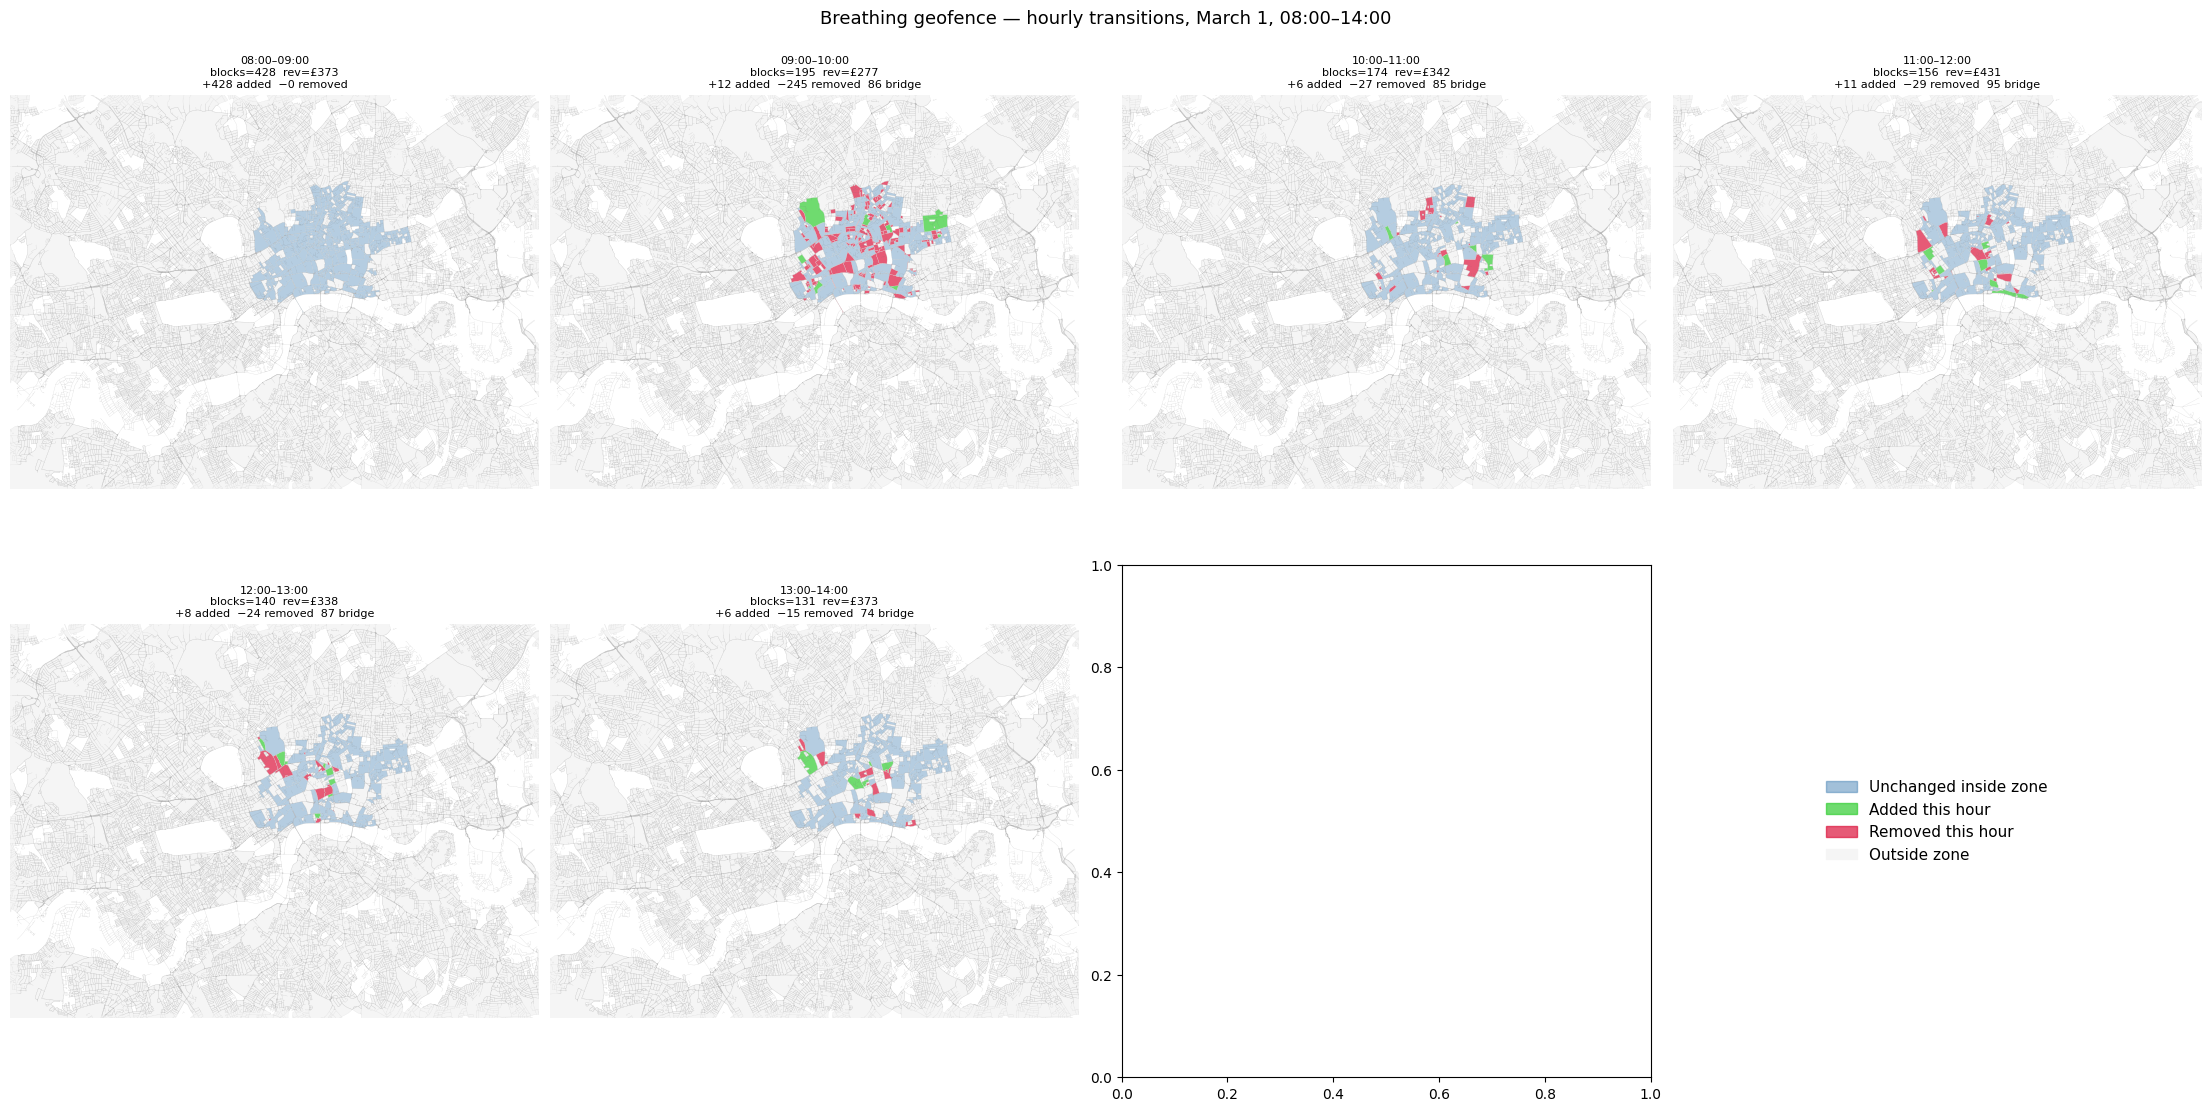

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11), constrained_layout=True)
axes_flat = axes.flatten()

for i, (h, sel) in enumerate(zip(HOURS, geofences)):
    ax   = axes_flat[i]
    prev = geofences[i - 1] if i > 0 else sel  # hour 8: no diff
    st   = stats_list[i]
    rev  = revenues[i]
    title = (
        f"{h:02d}:00\u2013{h+1:02d}:00\n"
        f"blocks={len(sel)}  rev=\u00a3{rev:,.0f}\n"
        f"+{st['n_added']} added  \u2212{st['n_removed']} removed"
        + (f"  {st['n_bridge_blocks']} bridge" if st['n_bridge_blocks'] > 0 else "")
    )
    plot_transition(ax, blocks_main, roads, prev, sel, bbox_bounds, title)

# 8th panel: legend
ax_leg = axes_flat[7]
patches = [
    mpatches.Patch(color="steelblue", alpha=0.5, label="Unchanged inside zone"),
    mpatches.Patch(color="limegreen", alpha=0.7, label="Added this hour"),
    mpatches.Patch(color="crimson",   alpha=0.7, label="Removed this hour"),
    mpatches.Patch(color="#f5f5f5",              label="Outside zone"),
]
ax_leg.legend(handles=patches, loc="center", fontsize=11, frameon=False)
ax_leg.set_axis_off()

fig.suptitle(
    "Breathing geofence \u2014 hourly transitions, March 1, 08:00\u201314:00",
    fontsize=13,
)
plt.show()

## 8. Revenue comparison — static vs. breathing

Static revenue per hour = what the fixed cumulative zone captures from that hour's trips.
Breathing revenue per hour = what the adapted zone captures.

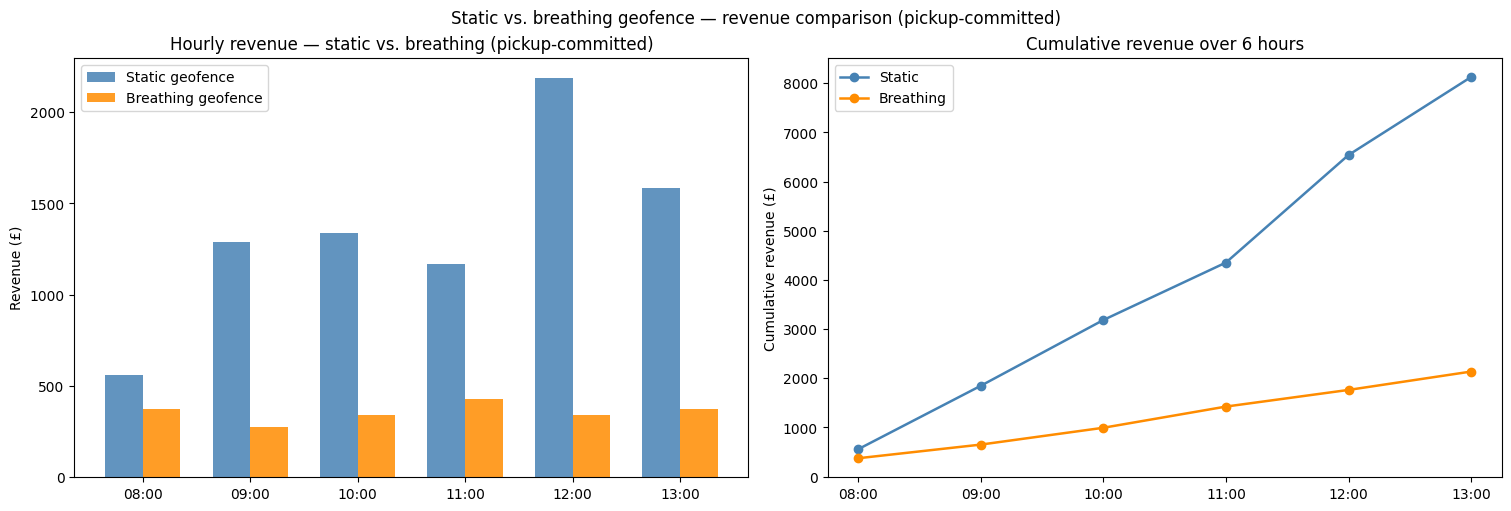

6-hour static total   : £8,123.96
6-hour breathing total: £2,135.39
Breathing gain        : £-5,988.57  (-73.71%)


In [9]:
static_hourly_rev = [
    compute_pickup_revenue(static_sel, hourly_lookups[h]) for h in HOURS
]

x         = np.arange(len(HOURS))
w         = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

# Per-hour bar chart
axes[0].bar(x - w/2, static_hourly_rev, width=w,
            label="Static geofence",    color="steelblue",  alpha=0.85)
axes[0].bar(x + w/2, revenues,          width=w,
            label="Breathing geofence", color="darkorange", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(hour_labels)
axes[0].set_ylabel("Revenue (£)")
axes[0].set_title("Hourly revenue — static vs. breathing (pickup-committed)")
axes[0].legend()

# Cumulative line chart
axes[1].plot(hour_labels, np.cumsum(static_hourly_rev), "o-",
             color="steelblue",  linewidth=1.8, label="Static")
axes[1].plot(hour_labels, np.cumsum(revenues), "o-",
             color="darkorange", linewidth=1.8, label="Breathing")
axes[1].set_ylabel("Cumulative revenue (£)")
axes[1].set_title("Cumulative revenue over 6 hours")
axes[1].legend()

fig.suptitle("Static vs. breathing geofence — revenue comparison (pickup-committed)", fontsize=12)
plt.show()

total_static  = sum(static_hourly_rev)
total_dynamic = sum(revenues)
delta         = total_dynamic - total_static
print(f"6-hour static total   : £{total_static:,.2f}")
print(f"6-hour breathing total: £{total_dynamic:,.2f}")
print(f"Breathing gain        : £{delta:+,.2f}  ({100*delta/total_static:+.2f}%)")

## 9. Summary table

In [10]:
summary = pd.DataFrame(stats_list)
summary["window"]      = summary["hour"].map(lambda h: f"{h:02d}:00\u2013{h+1:02d}:00")
summary["static_rev"]  = static_hourly_rev
summary["dynamic_rev"] = revenues
summary["delta_gbp"]   = summary["dynamic_rev"] - summary["static_rev"]
summary["delta_pct"]   = (100 * summary["delta_gbp"] / summary["static_rev"]).round(2)

print("=" * 100)
print("BREATHING GEOFENCE SUMMARY \u2014 March 1, 08:00\u201314:00")
print("=" * 100)
print(
    summary[[
        "window", "n_blocks", "area_sqkm",
        "n_added", "n_removed", "n_swapped", "n_bridge_blocks",
        "static_rev", "dynamic_rev", "delta_gbp", "delta_pct",
    ]].to_string(index=False, float_format=lambda x: f"{x:,.2f}")
)
print("=" * 100)
print(f"6-hour static total   : \u00a3{summary['static_rev'].sum():,.2f}")
print(f"6-hour dynamic total  : \u00a3{summary['dynamic_rev'].sum():,.2f}")
delta_total = summary["dynamic_rev"].sum() - summary["static_rev"].sum()
print(
    f"Breathing improvement : \u00a3{delta_total:+,.2f}  "
    f"({100*delta_total/summary['static_rev'].sum():+.2f}%)"
)
print("=" * 100)

BREATHING GEOFENCE SUMMARY — March 1, 08:00–14:00
     window  n_blocks  area_sqkm  n_added  n_removed  n_swapped  n_bridge_blocks  static_rev  dynamic_rev  delta_gbp  delta_pct
08:00–09:00       428      13.00      428          0          0                0      558.47       373.44    -185.03     -33.13
09:00–10:00       195      10.93       12        245          1               86    1,289.45       277.34  -1,012.11     -78.49
10:00–11:00       174      10.46        6         27          3               85    1,336.67       342.26    -994.41     -74.39
11:00–12:00       156      10.06       11         29          3               95    1,167.79       430.61    -737.18     -63.13
12:00–13:00       140       9.47        8         24          1               87    2,186.55       338.38  -1,848.17     -84.52
13:00–14:00       131       9.50        6         15          0               74    1,585.03       373.36  -1,211.67     -76.44
6-hour static total   : £8,123.96
6-hour dynamic total